In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc

import joblib

# Loading Data & Preprocessor

In [2]:
# Load raw train/test splits
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

# squeeze() — converts y from 2D (n_samples, 1) to 1D (n_samples,) as required by sklearn
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Load preprocessor
preprocessor = joblib.load('../models/preprocessor.joblib')

In [3]:
print(f"X_train shape: {X_train.shape}") 
print(f"X_test shape: {X_test.shape}")

X_train shape: (80000, 14)
X_test shape: (20000, 14)


# 9. Model Training and Evaluation

## 9.1 - Logistic Regression

#### Training:

In [4]:
# Pipeline — chains preprocessor and model into a single object
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=2, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

#### Metrics:

In [5]:
# Evaluation Metrics
print(f"Logistic Regression Accuracy:  {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1]):.4f}")

Logistic Regression Accuracy:  76.00%
ROC-AUC:   0.8393


#### Classification Report:

In [6]:
# shows precision, recall, f1-score for each class
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79     11122
           1       0.75      0.68      0.72      8878

    accuracy                           0.76     20000
   macro avg       0.76      0.75      0.75     20000
weighted avg       0.76      0.76      0.76     20000



#### Confusion Matrix:

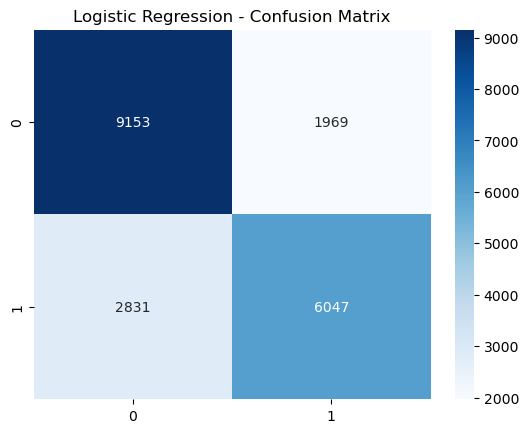

In [7]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()
plt.close()

#### 9.1.1 - Logistic Regression with Balanced Class Weight

In [8]:
lr_balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', LogisticRegression(random_state=2, max_iter=1000, class_weight='balanced'))
])

lr_balanced_pipeline.fit(X_train, y_train)
y_pred_lr_balanced = lr_balanced_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_balanced) * 100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_balanced_pipeline.predict_proba(X_test)[:, 1]):.4f}")
print() 
print(classification_report(y_test, y_pred_lr_balanced))

Accuracy: 75.87%
ROC-AUC: 0.8393

              precision    recall  f1-score   support

           0       0.79      0.78      0.78     11122
           1       0.72      0.74      0.73      8878

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



## 9.2 - Decision Tree

#### Training:

In [9]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('model', DecisionTreeClassifier(random_state=2))
])

dt_pipeline.fit(X_train, y_train) 
y_pred_dt = dt_pipeline.predict(X_test)

#### Metrics:

In [10]:
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt) * 100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, dt_pipeline.predict_proba(X_test)[:, 1]):.4f}")

Decision Tree Accuracy: 66.57%
ROC-AUC: 0.6619


#### Classification Report: 

In [11]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70     11122
           1       0.62      0.63      0.62      8878

    accuracy                           0.67     20000
   macro avg       0.66      0.66      0.66     20000
weighted avg       0.67      0.67      0.67     20000



#### Confusion Matrix:

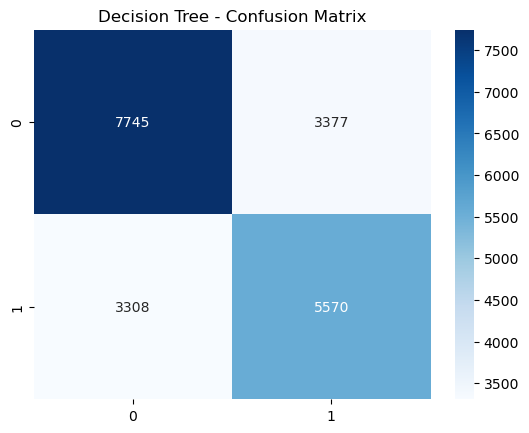

In [12]:
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.show()
plt.close() 

## 9.3 - Random Forest

#### Training:

In [13]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', RandomForestClassifier(random_state=2))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

#### Metrics: 

In [14]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:, 1]):.4f}")

Random Forest Accuracy: 75.25
ROC-AUC: 0.8278


#### Classification Report:

In [15]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79     11122
           1       0.75      0.67      0.71      8878

    accuracy                           0.75     20000
   macro avg       0.75      0.74      0.75     20000
weighted avg       0.75      0.75      0.75     20000



#### Confusion Matrix:

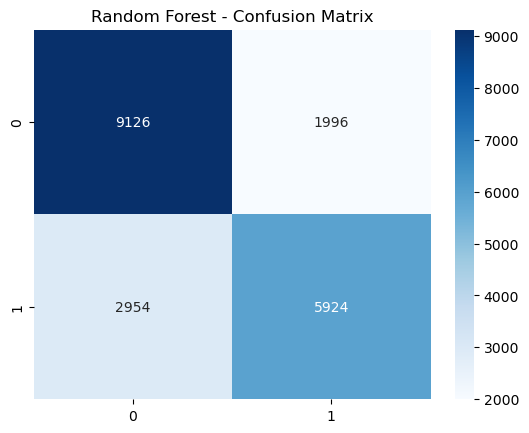

In [16]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()
plt.close()

## 9.4 - XGBoost

#### Training: 

In [17]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', XGBClassifier(random_state=2, eval_metric='logloss'))
])

xgb_pipeline.fit(X_train, y_train) 
y_pred_xgb = xgb_pipeline.predict(X_test)

#### Metrics:

In [18]:
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_pipeline.predict_proba(X_test)[:, 1]):.4f}")

XGBoost Accuracy: 75.44%
ROC-AUC: 0.8303


#### Classification Report: 

In [19]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.76      0.81      0.79     11122
           1       0.74      0.68      0.71      8878

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000



#### Confusion Matrix: 

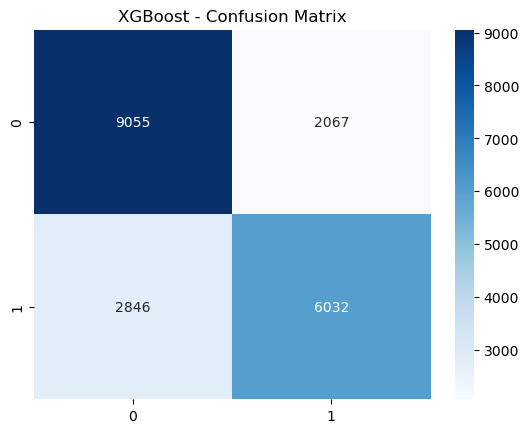

In [20]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost - Confusion Matrix')
plt.show()
plt.close() 

### Model Comparision: 

In [21]:
# Model Comparison
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_lr) * 100, 2),
        round(accuracy_score(y_test, y_pred_dt) * 100, 2),
        round(accuracy_score(y_test, y_pred_rf) * 100, 2),
        round(accuracy_score(y_test, y_pred_xgb) * 100, 2)
    ],
    "ROC-AUC": [
        round(roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, dt_pipeline.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, xgb_pipeline.predict_proba(X_test)[:, 1]), 4)
    ]
}

pd.DataFrame(results).sort_values("Accuracy", ascending=False)

,Model,Accuracy,ROC-AUC
0,Logistic Regression,76.00,0.8393
3,XGBoost,75.44,0.8303
2,Random Forest,75.25,0.8278
1,Decision Tree,66.57,0.6619


## 9.6 - Model Comparison Bar Chart

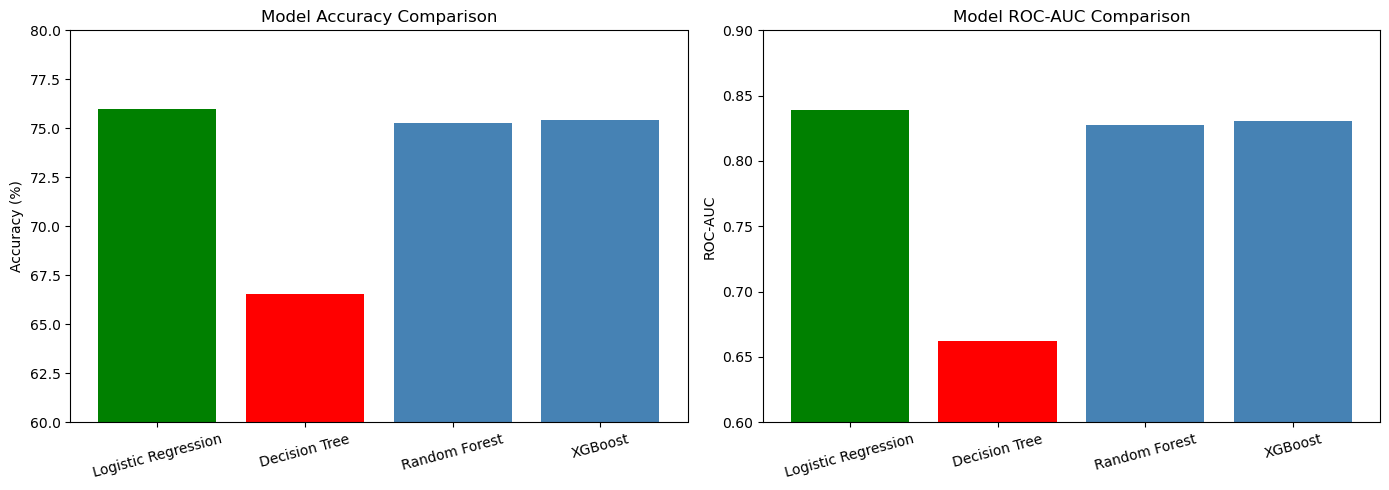

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]
accuracies = [76.00, 66.57, 75.25, 75.44]
roc_aucs = [0.8393, 0.6619, 0.8278, 0.8303]

# Accuracy Chart
axes[0].bar(models, accuracies, color=['green', 'red', 'steelblue', 'steelblue'])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(60, 80)
axes[0].tick_params(axis='x', rotation=15)

# ROC-AUC Chart
axes[1].bar(models, roc_aucs, color=['green', 'red', 'steelblue', 'steelblue'])
axes[1].set_title('Model ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.60, 0.90)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
plt.close()

## 9.7 - Cross Validation (CV)

#### 9.7.1 -  Cross Validation (Logistic Regression)

In [23]:
# cross_val_score - evaluates model performance across multiple folds
# cv=5 - splits data into 5 parts, trains 5 times, each time different test fold
# scroling='roc_auc' - uses ROC-AUC  as evaluation metric
cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='roc_auc')

print(f"CV Scores: {cv_scores}")
print(f"Mean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

CV Scores: [0.83985998 0.83697916 0.84077137 0.84254346 0.83542472]
Mean ROC-AUC: 0.8391
Standard Deviation: 0.0026


#### 9.7.2 - Cross Validation (Dicision Tree)

In [24]:
cv_scores_dt = cross_val_score(dt_pipeline, X_train, y_train, cv=5, scoring='roc_auc')

print(f"CV Scores: {cv_scores_dt}")
print(f"Mean ROC-AUC: {cv_scores_dt.mean():.4f}")
print(f"Standard Deviation: {cv_scores_dt.std():.4f}")

CV Scores: [0.6652819  0.65694047 0.66925611 0.65450645 0.66178959]
Mean ROC-AUC: 0.6616
Standard Deviation: 0.0054


#### 9.7.3 - Cross Validation (Random Forest)

In [25]:
cv_scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='roc_auc')

print(f"CV Score: {cv_scores_rf}")
print(f"Mean ROC-AUC: {cv_scores_rf.mean():.4f}")
print(f"Standard Deviation: {cv_scores_rf.std():.4f}")

CV Score: [0.82964206 0.8240738  0.82807362 0.82905733 0.82228461]
Mean ROC-AUC: 0.8266
Standard Deviation: 0.0029


#### 9.7.4 - Cross Validation (XGBoost)

In [26]:
cv_scores_xgb = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='roc_auc')

print(f"CV Scores: {cv_scores_xgb}")
print(f"Mean ROC-AUC: {cv_scores_xgb.mean():.4f}")
print(f"Strand Deviation: {cv_scores_xgb.std():.4f}")

CV Scores: [0.82971821 0.82513049 0.83348901 0.83361614 0.8250393 ]
Mean ROC-AUC: 0.8294
Strand Deviation: 0.0038


## 9.8 - ROC-AUC Curve

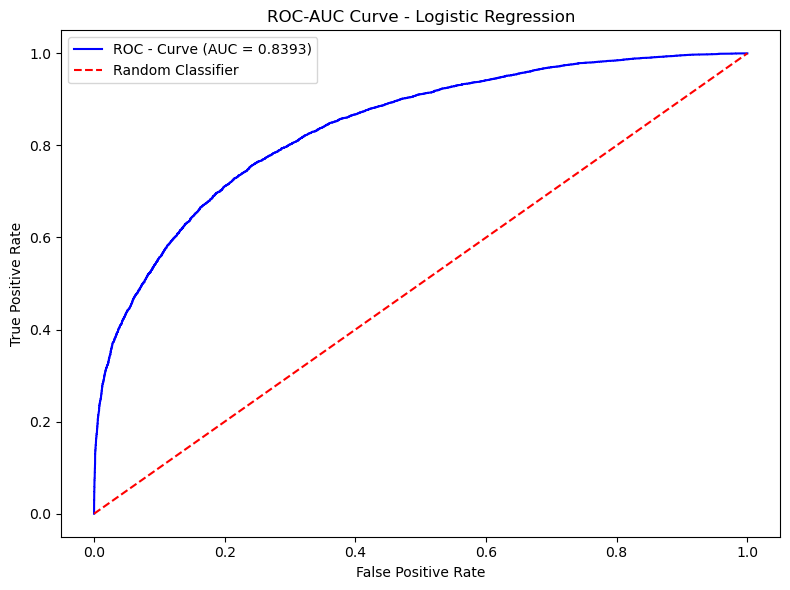

In [27]:
# Get prediction probabilities for positive class
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Calculate ROC curve points
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC - Curve (AUC = {roc_auc:.4f})')

# Random classifier baseline 
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')

plt.title('ROC-AUC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show() 
plt.close() 

## 9.9 - Feature Importance (Final Model: Logistic Regression)

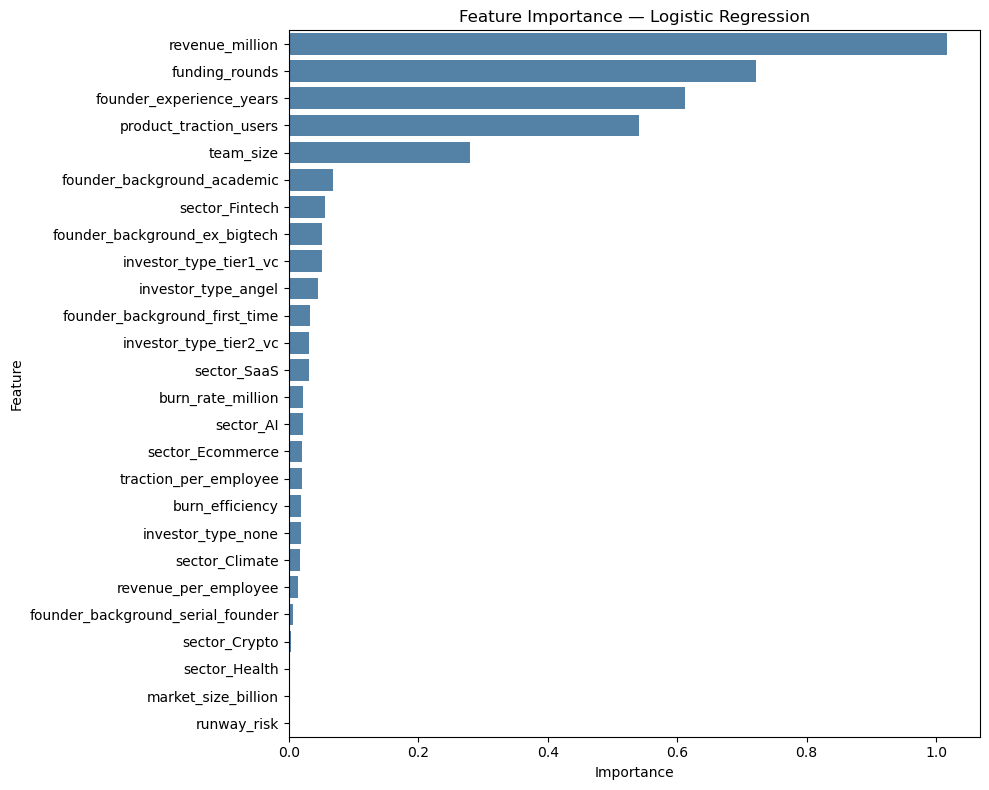

In [28]:
# Extract feature names after preprocessing 
cat_cols = ['investor_type', 'sector', 'founder_background']
numeric_cols = ['funding_rounds', 'founder_experience_years', 'team_size', 'market_size_billion',
               'product_traction_users', 'burn_rate_million', 'revenue_million', 'burn_efficiency',
               'revenue_per_employee', 'traction_per_employee', 'runway_risk']

# Get feature names from preprocessor
ohe_features = lr_pipeline.named_steps['preprocessor']\
                .named_transformers_['cat']\
                .get_feature_names_out(cat_cols).tolist()

all_features = numeric_cols + ohe_features

# Extract coefficients from Logistic Regression
coefficients = lr_pipeline.named_steps['model'].coef_[0]

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': abs(coefficients)
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='steelblue')
plt.title('Feature Importance — Logistic Regression')
plt.tight_layout()
plt.show()
plt.close()

## 9.10 - Save Final Pipeline 

In [29]:
# Save final pipeline — preprocessor + balanced logistic regression model in one object
joblib.dump(lr_balanced_pipeline, '../models/final_pipeline.joblib')

['../models/final_pipeline.joblib']

## Conclusion

- 4 models trained: Logistic Regression, Decision Tree, Random Forest, XGBoost
- Logistic Regression best performer — 76% accuracy, 0.8393 ROC-AUC
- Balanced class weight applied to Logistic Regression — improved Success class recall from 0.68 to 0.74
- 5-fold cross validation confirmed model stability — 0.8391 mean ROC-AUC, 0.0026 std
- Revenue and funding rounds are the most influential features in startup success prediction
- Final pipeline saved with balanced class weight — optimized for investor perspective to minimize missed opportunities